# benchmark visual por janela

Notebook para comparar a acuracia dos modelos, temporada a temporada

- Fonte dos dados: `results/experimento_03_detalhado` (predicoes detalhadas de cada modelo, jogo a jogo)
- Uma figura para cada janela: `5`, `10` e `15`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'results' / 'experimento_03_detalhado').exists():
            return candidate
    raise FileNotFoundError(
        'Nao foi possivel localizar a raiz do projeto com a pasta results/experimento_03_detalhado.'
    )


BASE_DIR = find_project_root(Path.cwd())
PASTA_DETALHADO = BASE_DIR / 'results' / 'experimento_03_detalhado'
JANELAS = [5, 10, 15]

MODELOS = {
    'SVM':                 'svm_experimento_03_predicoes_detalhadas.csv',
    'KNN':                 'knn_experimento_03_predicoes_detalhadas.csv',
    'Extra Trees':         'extra_trees_experimento_03_predicoes_detalhadas.csv',
    'Regressao Logistica': 'regressao_logistica_experimento_03_predicoes_detalhadas.csv',
    'LightGBM':            'lightgbm_experimento_03_predicoes_detalhadas.csv',
}

# mesmas cores/marcadores usados no plot_comparativo do stack_ensemble.ipynb
CORES = {
    'SVM':                 '#1f77b4',
    'KNN':                 '#ff7f0e',
    'Extra Trees':         '#2ca02c',
    'Regressao Logistica': '#d62728',
    'LightGBM':            '#9467bd',
}

MARCADORES = {
    'SVM':                 'o',
    'KNN':                 's',
    'Extra Trees':         '^',
    'Regressao Logistica': 'D',
    'LightGBM':            'P',
}

print(f'BASE_DIR: {BASE_DIR}')
print(f'PASTA_DETALHADO: {PASTA_DETALHADO}')

BASE_DIR: C:\Users\pedro.negreiro\Documents\stack-ensemble-prediction
PASTA_DETALHADO: C:\Users\pedro.negreiro\Documents\stack-ensemble-prediction\results\experimento_03_detalhado


## Carregar resultados de uma janela

Para cada modelo, li o CSV detalhado, filtrei pela janela pedida e calculei por temporada. 

In [2]:
def load_window_results(janela):
    acc_por_modelo = {}
    jogos_por_temporada = None

    for nome_modelo, arquivo in MODELOS.items():
        df = pd.read_csv(PASTA_DETALHADO / arquivo)
        df = df[df['Janela Incremental'] == janela]

        acerto = (df['Previsao'] == df['Resultado Real'])
        acc_por_modelo[nome_modelo] = acerto.groupby(df['Temporada']).mean()

        contagem = df.groupby('Temporada').size()
        jogos_por_temporada = contagem if jogos_por_temporada is None else jogos_por_temporada

    temporadas_order = sorted(jogos_por_temporada.index)

    acuracia = pd.DataFrame({m: s.reindex(temporadas_order) for m, s in acc_por_modelo.items()}, index=temporadas_order)
    jogos = jogos_por_temporada.reindex(temporadas_order)

    return acuracia, jogos, temporadas_order

## Grafico da janela

In [3]:
def plot_janela(janela):
    acuracia, jogos, temporadas_order = load_window_results(janela)

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(16, 9),
        gridspec_kw={'height_ratios': [3, 1]},
        sharex=True
    )

    for nome_modelo in MODELOS.keys():
        ax1.plot(
            acuracia.index,
            acuracia[nome_modelo],
            marker=MARCADORES[nome_modelo],
            color=CORES[nome_modelo],
            linewidth=1.5,
            markersize=5,
            label=nome_modelo,
            alpha=0.5
        )

    ax1.set_title(
        f'Experimento 03 - Acuracia por temporada | Janela = {janela}',
        fontsize=14
    )
    ax1.set_ylabel('Acuracia', fontsize=12)
    ax1.set_ylim(0.45, 0.90)
    ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
    ax1.legend(loc='upper right', fontsize=9, ncol=2)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    ax1.tick_params(axis='x', rotation=45)

    ax2.bar(
        temporadas_order, jogos.values,
        color='#1f77b4', alpha=0.4, edgecolor='#1f77b4'
    )
    for i, v in enumerate(jogos.values):
        ax2.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=8)

    ax2.set_ylabel('Jogos', fontsize=10)
    ax2.set_ylim(0, max(jogos.values) * 1.25)
    ax2.grid(axis='y', linestyle='--', alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    display(acuracia.style.format('{:.4f}'))

    return acuracia, jogos

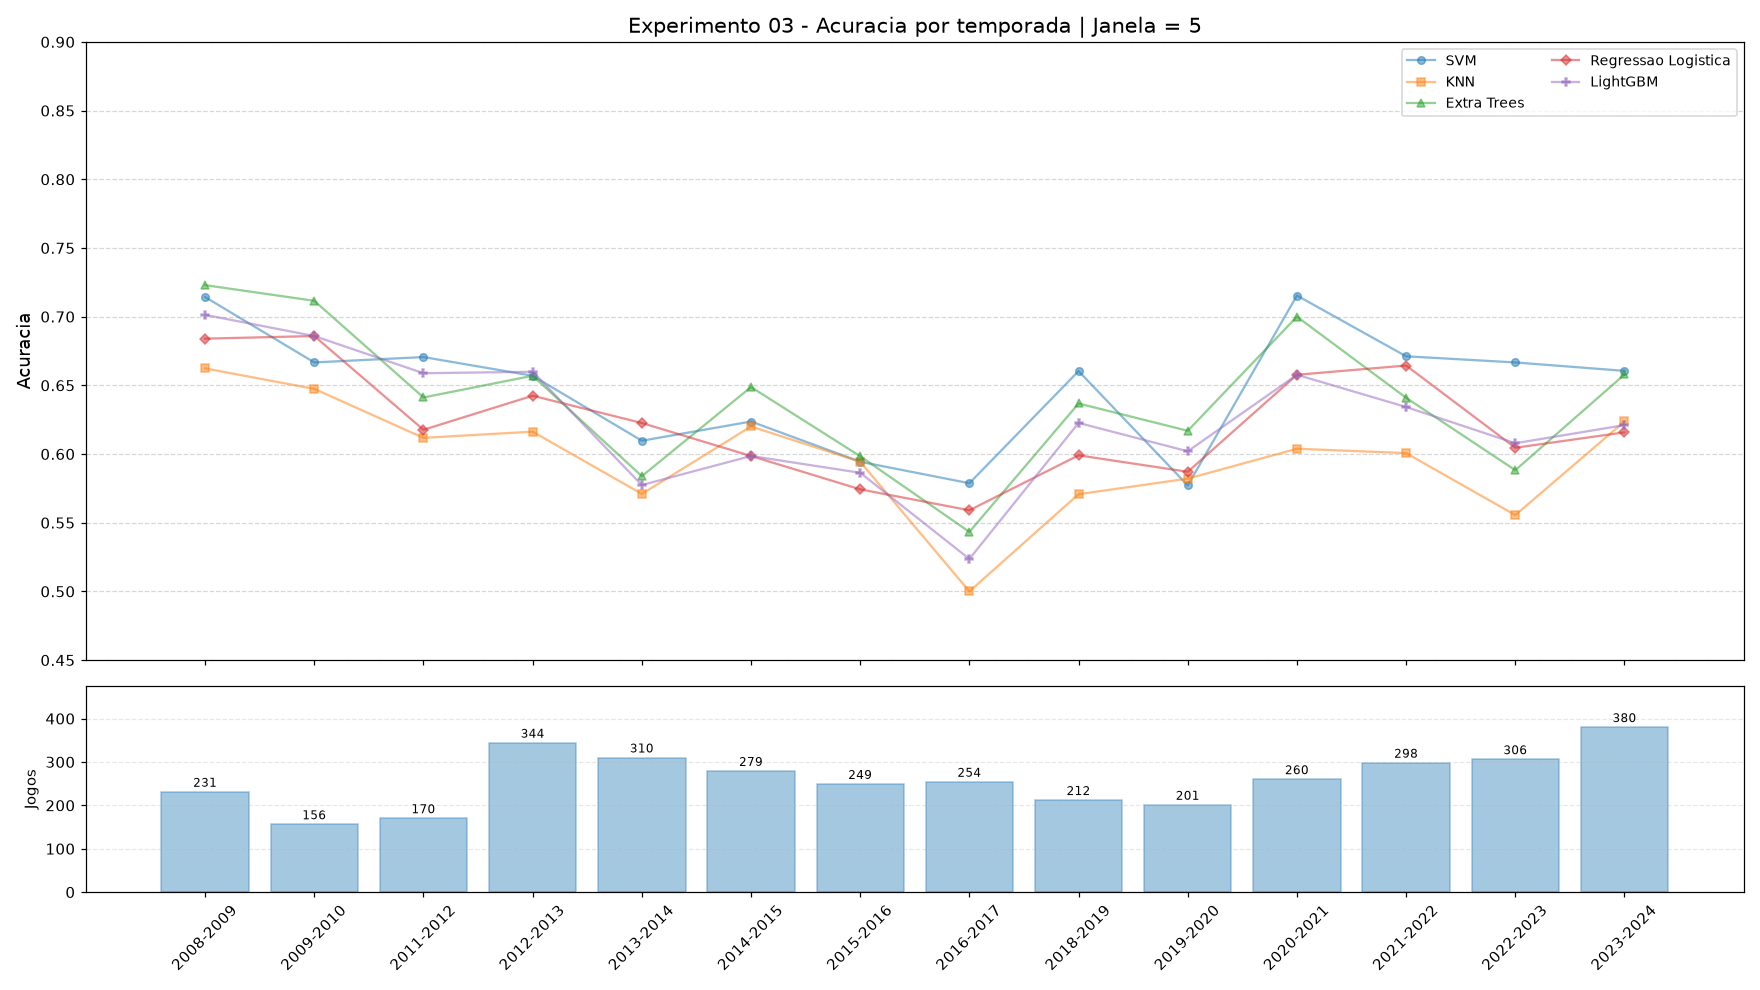

,SVM,KNN,Extra Trees,Regressao Logistica,LightGBM
2008-2009,0.7143,0.6623,0.7229,0.6840,0.7013
2009-2010,0.6667,0.6474,0.7115,0.6859,0.6859
2011-2012,0.6706,0.6118,0.6412,0.6176,0.6588
2012-2013,0.6570,0.6163,0.6570,0.6424,0.6599
2013-2014,0.6097,0.5710,0.5839,0.6226,0.5774
2014-2015,0.6237,0.6201,0.6487,0.5986,0.5986
2015-2016,0.5944,0.5944,0.5984,0.5743,0.5863
2016-2017,0.5787,0.5000,0.5433,0.5591,0.5236
2018-2019,0.6604,0.5708,0.6368,0.5991,0.6226
2019-2020,0.5771,0.5821,0.6169,0.5871,0.6020


In [4]:
plot_janela(5)

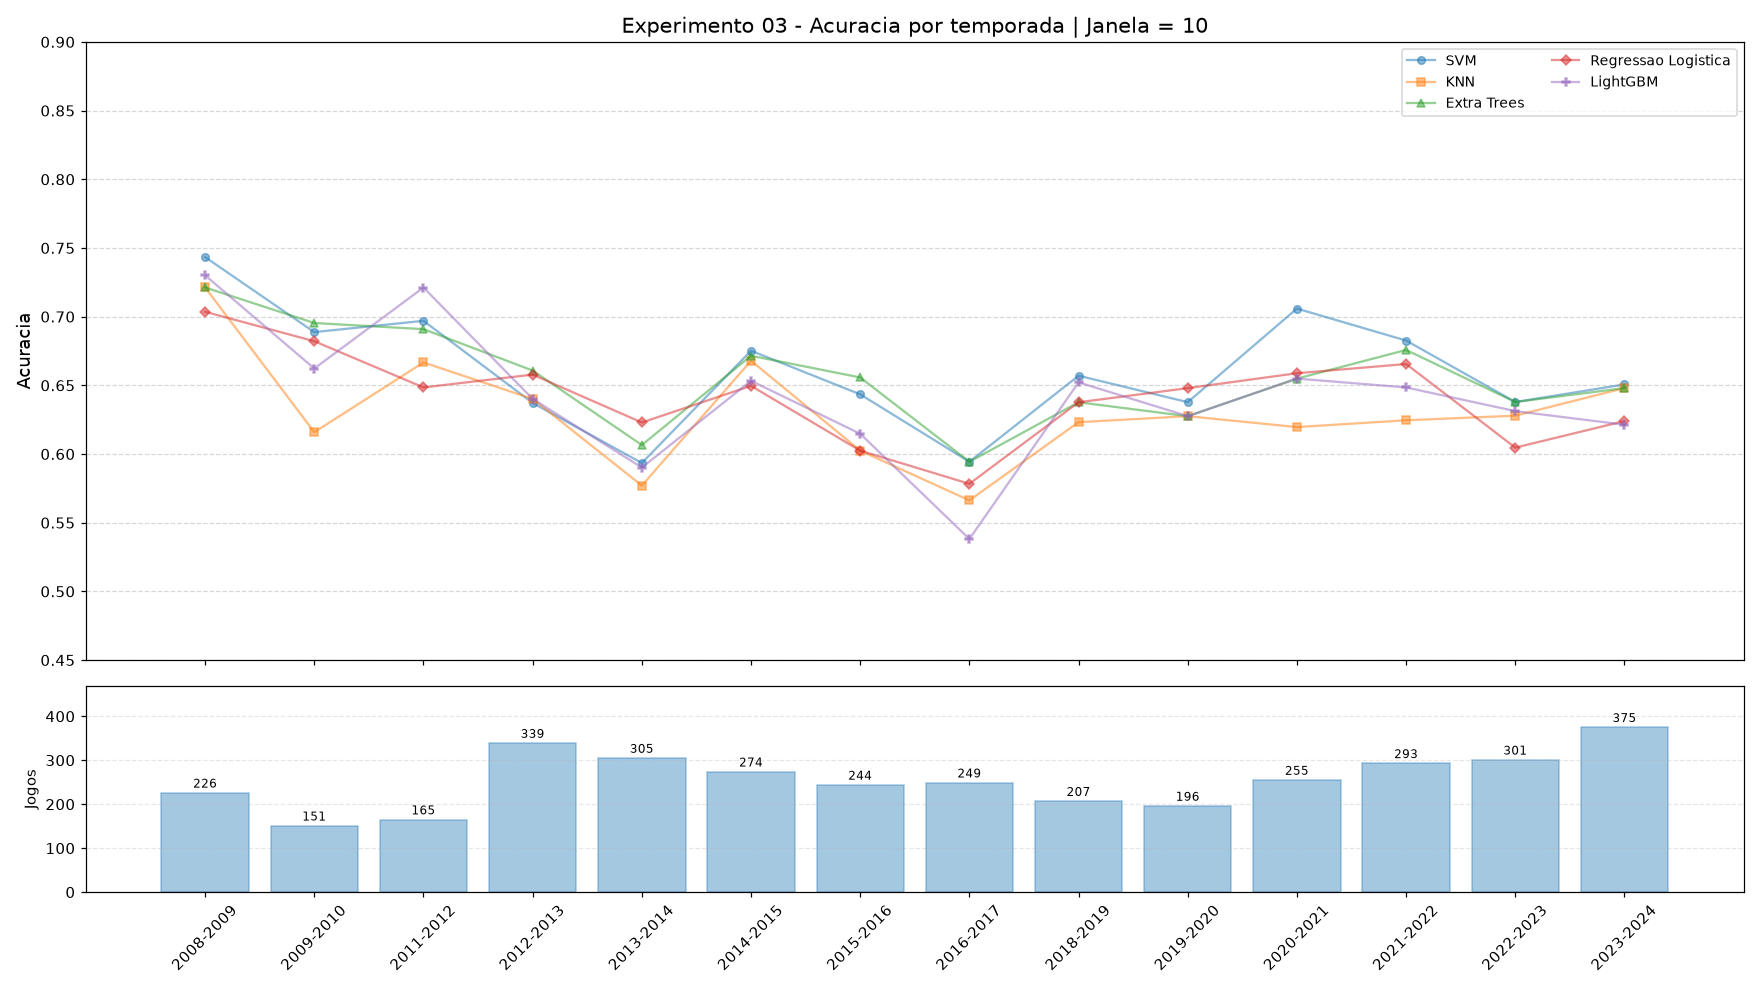

,SVM,KNN,Extra Trees,Regressao Logistica,LightGBM
2008-2009,0.7434,0.7212,0.7212,0.7035,0.7301
2009-2010,0.6887,0.6159,0.6954,0.6821,0.6623
2011-2012,0.6970,0.6667,0.6909,0.6485,0.7212
2012-2013,0.6372,0.6401,0.6608,0.6578,0.6401
2013-2014,0.5934,0.5770,0.6066,0.6230,0.5902
2014-2015,0.6752,0.6679,0.6715,0.6496,0.6533
2015-2016,0.6434,0.6025,0.6557,0.6025,0.6148
2016-2017,0.5944,0.5663,0.5944,0.5783,0.5382
2018-2019,0.6570,0.6232,0.6377,0.6377,0.6522
2019-2020,0.6378,0.6276,0.6276,0.6480,0.6276


In [5]:
plot_janela(10)

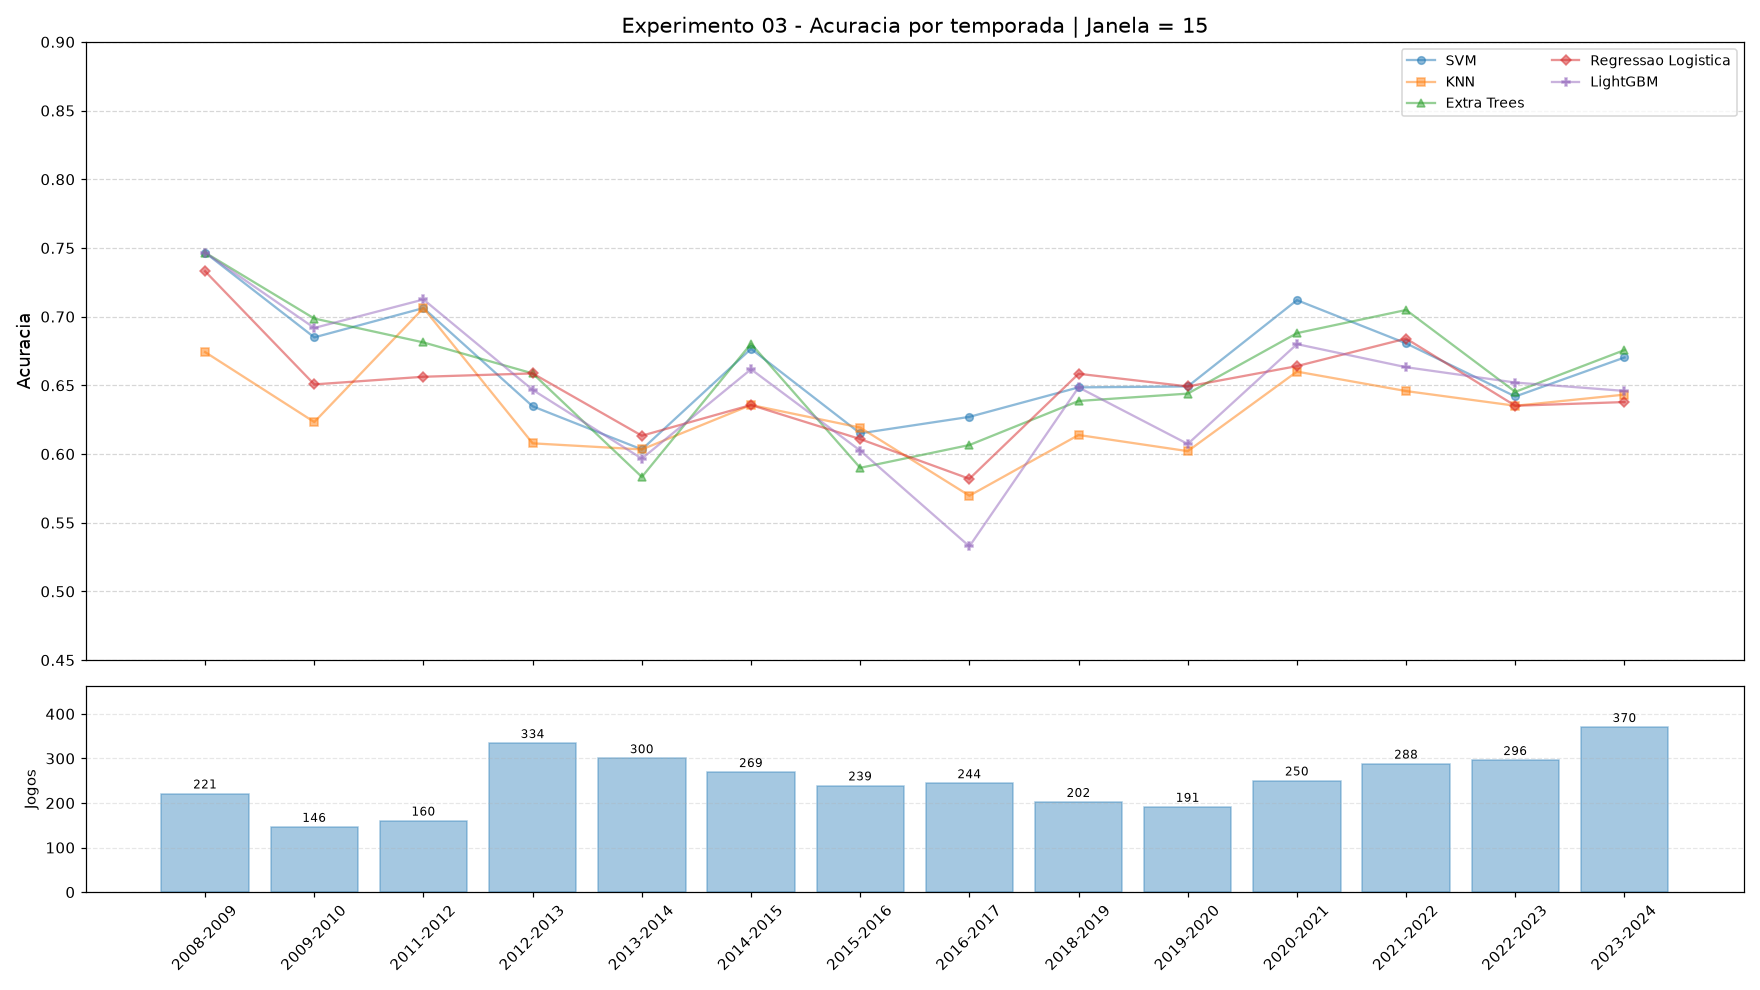

,SVM,KNN,Extra Trees,Regressao Logistica,LightGBM
2008-2009,0.7466,0.6742,0.7466,0.7330,0.7466
2009-2010,0.6849,0.6233,0.6986,0.6507,0.6918
2011-2012,0.7063,0.7063,0.6813,0.6562,0.7125
2012-2013,0.6347,0.6078,0.6587,0.6587,0.6467
2013-2014,0.6033,0.6033,0.5833,0.6133,0.5967
2014-2015,0.6766,0.6357,0.6803,0.6357,0.6617
2015-2016,0.6151,0.6192,0.5900,0.6109,0.6025
2016-2017,0.6270,0.5697,0.6066,0.5820,0.5328
2018-2019,0.6485,0.6139,0.6386,0.6584,0.6485
2019-2020,0.6492,0.6021,0.6440,0.6492,0.6073


In [6]:
plot_janela(15)